# General Time Series Forecaster

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/ts-forecaster/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/ts-forecaster/demo.ipynb)

> "Forecast any metric" — Holt-Winters (trend + seasonality) implemented in pure numpy, with honest backtest accuracy.

You don't always need Prophet or a heavy dependency to forecast a monthly metric. **Holt-Winters**
(triple exponential smoothing) captures level, trend, and seasonality in a few lines of numpy - and,
just as important, you *backtest* it so you know how much to trust the numbers.

**What this notebook covers**
1. A metric with trend + seasonality
2. Holt-Winters decomposition into level / trend / season
3. Forecasting with a widening uncertainty band
4. Backtesting for honest accuracy (MAPE)
5. The forecast, visualized


## Step 1 - A seasonal metric

Four years of monthly data: a steady upward trend plus a yearly wave. The forecaster needs to learn
both, not just draw a straight line.

In [1]:
from forecaster import holt_winters_add, backtest, sample_series

s = sample_series()
print(s.head(6).to_string())
print("...")
print(f"{len(s)} monthly points, seasonal period 12.")


2022-01-01    1061.0
2022-02-01     991.0
2022-03-01    1132.0
2022-04-01    1127.0
2022-05-01    1122.0
2022-06-01    1094.0
Freq: MS
...
48 monthly points, seasonal period 12.


## Step 2 - Forecast the next year

Holt-Winters smooths three components and projects them forward. The uncertainty band widens with the
horizon - honest about the fact that further-out forecasts are less certain.

In [2]:
fc = holt_winters_add(s.values, season=12, h=12)
print("Method:", fc.method)
print("Next 12 months:")
for i, v in enumerate(fc.forecast, 1):
    print(f"   +{i:2d}: {v:7.0f}   [{fc.lower[i-1]:7.0f}, {fc.upper[i-1]:7.0f}]")


Method: Holt-Winters (additive, season=12)
Next 12 months:
   + 1:    1374   [   1248,    1500]
   + 2:    1397   [   1219,    1575]
   + 3:    1468   [   1250,    1685]
   + 4:    1466   [   1214,    1717]
   + 5:    1476   [   1194,    1757]
   + 6:    1448   [   1140,    1757]
   + 7:    1356   [   1023,    1689]
   + 8:    1328   [    972,    1684]
   + 9:    1304   [    927,    1682]
   +10:    1372   [    974,    1770]
   +11:    1371   [    953,    1788]
   +12:    1411   [    975,    1847]


## Step 3 - Backtest = the only honest accuracy

A forecast that fits history perfectly can still be useless out-of-sample. We hold out the last 12
months, forecast them, and measure error against what actually happened.

In [3]:
bt = backtest(s.values, season=12, test_h=12)
print(f"Backtest MAPE: {bt['mape']:.1f}%   RMSE: {bt['rmse']:.1f}")
print("\n  actual   predicted")
for a, p in zip(bt["test"], bt["pred"]):
    print(f"  {a:7.0f}   {p:7.0f}")


Backtest MAPE: 4.6%   RMSE: 67.9

  actual   predicted
     1203      1284
     1387      1261
     1379      1362
     1382      1356
     1432      1356
     1409      1330
     1323      1238
     1252      1219
     1249      1186
     1238      1270
     1306      1242
     1338      1285


## Step 4 - Visualize history, fit, and forecast

History in blue, the model's in-sample fit dashed, the forecast in red with its confidence band. The
forecast should continue both the trend and the seasonal wave.

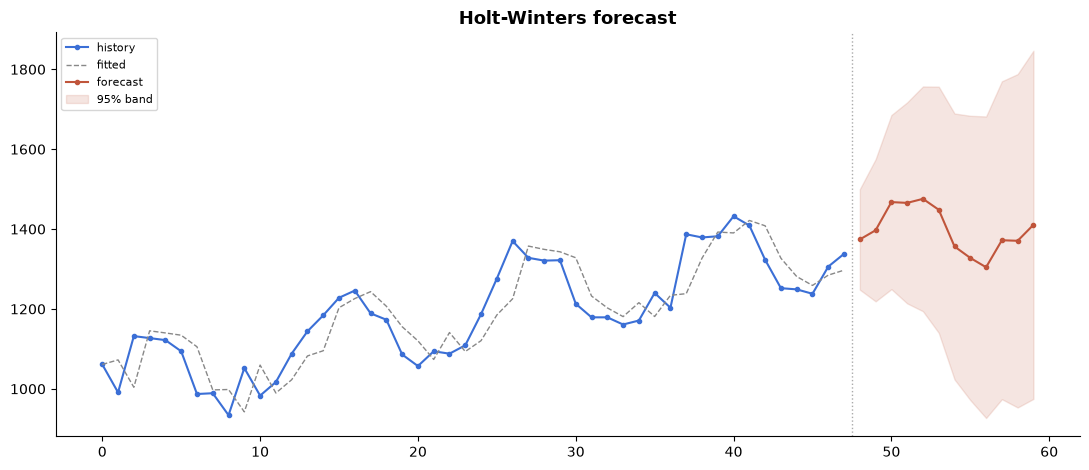

In [4]:
import matplotlib.pyplot as plt
import numpy as np

y = s.values
fc = holt_winters_add(y, 12, 12)
hx = np.arange(len(y))
fx = np.arange(len(y), len(y) + 12)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(hx, y, color="#3b6fd6", marker="o", ms=3, label="history")
ax.plot(hx, fc.fitted, color="#888", ls="--", lw=1, label="fitted")
ax.plot(fx, fc.forecast, color="#c0553b", marker="o", ms=3, label="forecast")
ax.fill_between(fx, fc.lower, fc.upper, color="#c0553b", alpha=0.15, label="95% band")
ax.axvline(len(y) - 0.5, color="#aaa", ls=":", lw=1)
ax.set_title("Holt-Winters forecast", fontsize=13, weight="bold")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("forecast.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Component | Captured by |
|-----------|-------------|
| level | α smoothing |
| trend | β smoothing |
| seasonality | γ smoothing (period-length) |
| accuracy | backtest MAPE |

Holt-Winters is the honest default for a metric with trend and seasonality: transparent, fast, no
heavy dependency, and always paired with a backtest. It falls back to Holt's linear method when there's
no season.

**Extend it:** auto-tune α/β/γ by minimizing backtest error, detect the seasonal period automatically,
and switch to a multiplicative model when seasonal swings scale with the level.

In [5]:
# --- Forecast your own series ---
# import pandas as pd, numpy as np
# y = pd.read_csv("metric.csv")["value"].values
# fc = holt_winters_add(y, season=12, h=6)
# print(fc.forecast)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 118,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`